In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ── Helper functions ───────────────────────────────────────────────────
def parse_number(val):
    """Convert ACS formatted string ('1,234' or '18.4%') to float."""
    if not isinstance(val, str):
        return None
    val = val.strip().replace(",", "").replace("%", "").replace("±", "")
    if val in ("", "-", "**", "(X)", "N"):
        return None
    try:
        return float(val)
    except ValueError:
        return None

def load_year(filepath):
    return pd.read_csv(filepath)

def find_row(df, keyword):
    label_col = df.columns[0]
    mask = df[label_col].str.strip().str.lower().str.contains(keyword.lower(), na=False)
    matches = df[mask]
    return matches.iloc[0] if len(matches) > 0 else None

def get_pct(row):
    if row is None: return None
    return parse_number(str(row.iloc[5]))

def get_total(row):
    if row is None: return None
    return parse_number(str(row.iloc[1]))

def get_below(row):
    if row is None: return None
    return parse_number(str(row.iloc[3]))

def get_moe(row):
    if row is None: return None
    return parse_number(str(row.iloc[6]))


In [2]:
# Use the full path to your CSV folder
DATA_DIR = "/Users/delilahhollander/Downloads/dsa400_SouthSide/poverty demographics"

files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith(".csv")])
years = []
data_frames = {}

for f in files:
    match = re.search(r"ACSST5Y(\d{4})", f)
    if match:
        year = int(match.group(1))
        years.append(year)
        data_frames[year] = load_year(os.path.join(DATA_DIR, f))

years.sort()
print(f"Loaded {len(years)} years: {years}")

# Build master long-form DataFrame
rows_list = []
categories_keywords = {
    "Overall": [("Population Total", "population for whom poverty status is determined")],
    "Age": [
        ("Under 18", "under 18 years"),
        ("18-64", "18 to 64 years"),
        ("65+", "65 years and over"),
    ],
    "Sex": [
        ("Male", "male"),
        ("Female", "female"),
    ],
    "Race": [
        ("White", "white alone"),
        ("Black", "black or african american"),
        ("Asian", "asian alone"),
        ("Two+ Races", "two or more races"),
        ("Hispanic/Latino", "hispanic or latino"),
    ],
    "Education": [
        ("< High School", "less than high school"),
        ("High School", "high school graduate"),
        ("Some College", "some college"),
        ("Bachelor's+", "bachelor's degree or higher"),
    ],
    "Employment": [
        ("Employed", "employed"),
        ("Unemployed", "unemployed"),
    ],
}

for y in years:
    df = data_frames[y]
    for cat, items in categories_keywords.items():
        for label, keyword in items:
            row = find_row(df, keyword)
            rows_list.append({
                "year": y,
                "category": cat,
                "group": label,
                "total": get_total(row),
                "below_poverty": get_below(row),
                "poverty_pct": get_pct(row),
                "moe": get_moe(row),
            })

master = pd.DataFrame(rows_list)
master['year'] = master['year'].astype(int)
print(f"Master DataFrame: {len(master)} rows")
master.head()


Loaded 11 years: [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Master DataFrame: 187 rows


,year,category,group,total,below_poverty,poverty_pct,moe
0,2014,Overall,Population Total,9891.0,2397.0,24.2,4.6
1,2014,Age,Under 18,643.0,93.0,14.5,12.7
2,2014,Age,18-64,8276.0,2169.0,26.2,5.1
3,2014,Age,65+,972.0,135.0,13.9,8.8
4,2014,Sex,Male,5349.0,1235.0,23.1,7.5


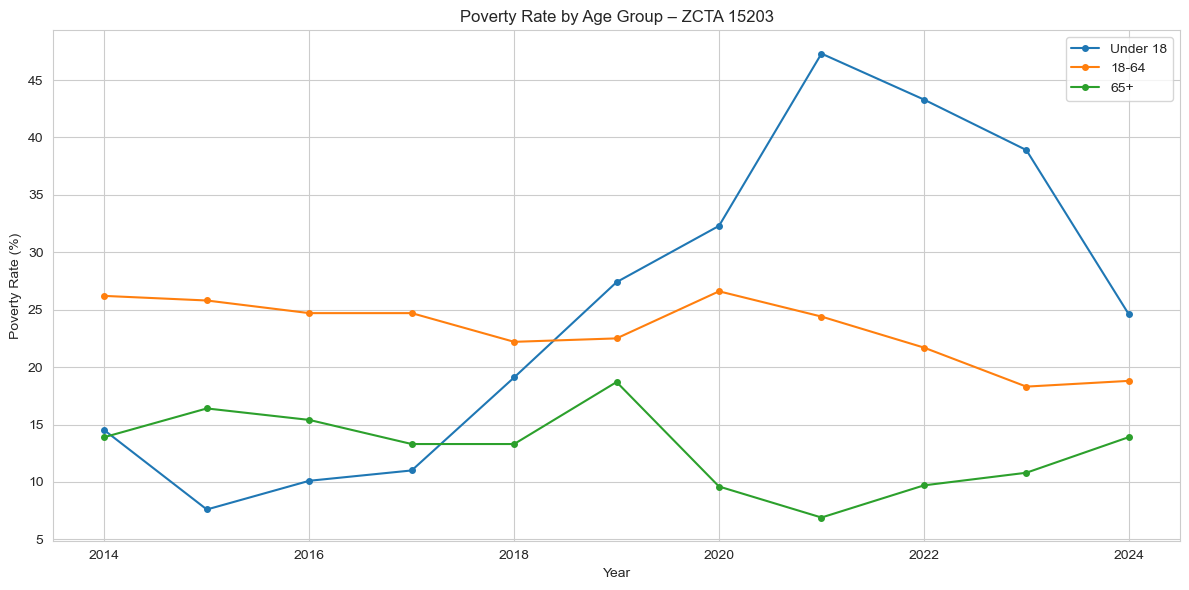

In [3]:
age_groups = ['Under 18', '18-64', '65+']
age_data = master[master['group'].isin(age_groups)]

plt.figure()
for name in age_groups:
    subset = age_data[age_data['group'] == name]
    plt.plot(subset['year'], subset['poverty_pct'], label=name, linewidth=1.5, marker='o', markersize=4)

plt.xlabel('Year')
plt.ylabel('Poverty Rate (%)')
plt.title('Poverty Rate by Age Group – ZCTA 15203')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

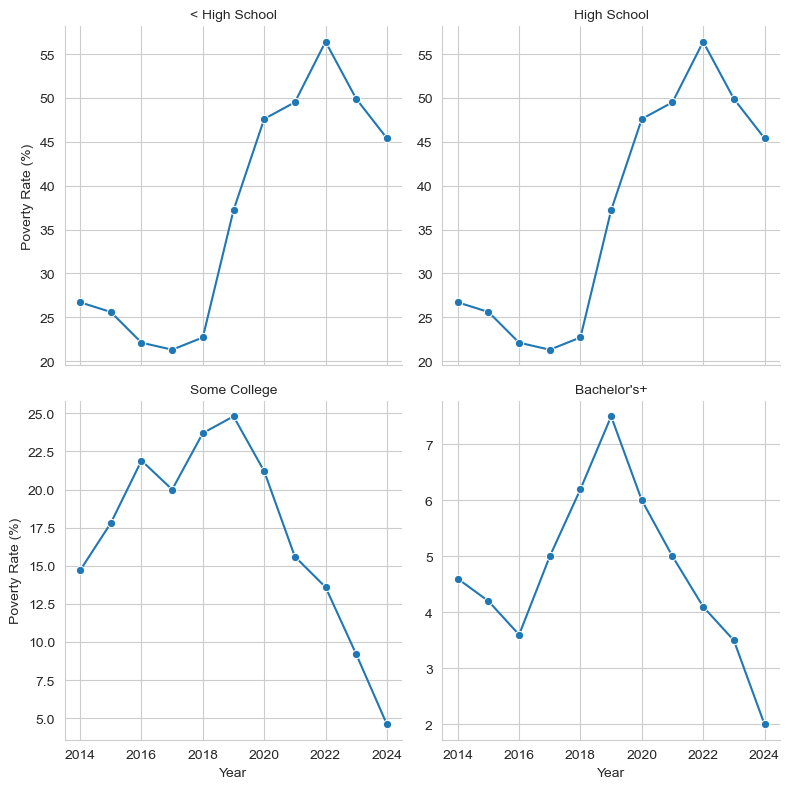

In [4]:
edu_groups = ['< High School', 'High School', 'Some College', "Bachelor's+"]
edu_data = master[master['group'].isin(edu_groups)].copy()

g = sns.FacetGrid(edu_data, col='group', col_wrap=2, height=4, sharey=False)
g.map_dataframe(sns.lineplot, x='year', y='poverty_pct', marker='o')
g.set_axis_labels('Year', 'Poverty Rate (%)')
g.set_titles(col_template='{col_name}')
g.tight_layout()
plt.show()

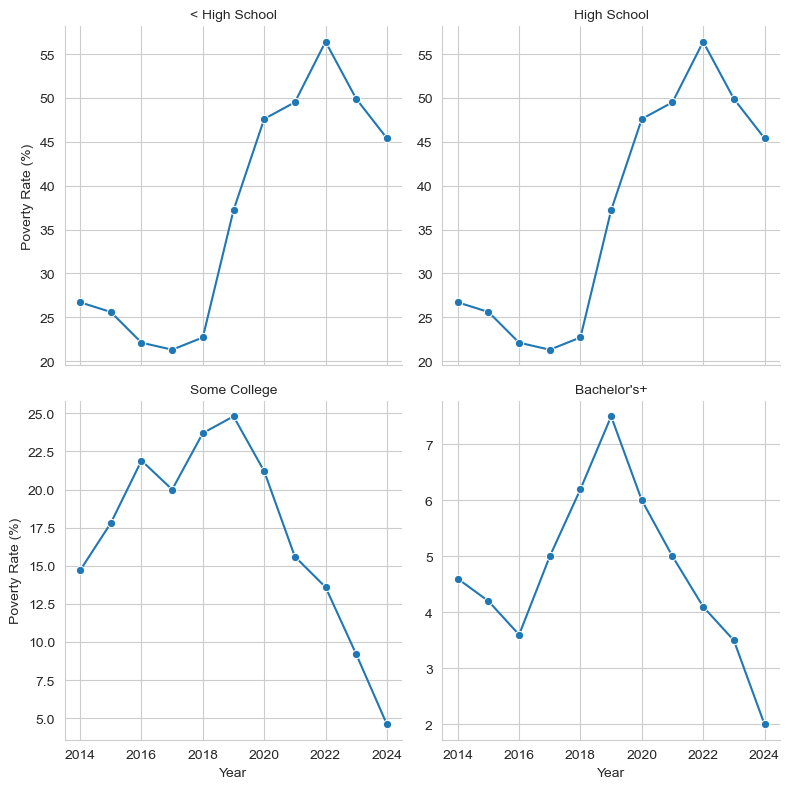

In [5]:
edu_groups = ['< High School', 'High School', 'Some College', "Bachelor's+"]
edu_data = master[master['group'].isin(edu_groups)].copy()

g = sns.FacetGrid(edu_data, col='group', col_wrap=2, height=4, sharey=False)
g.map_dataframe(sns.lineplot, x='year', y='poverty_pct', marker='o')
g.set_axis_labels('Year', 'Poverty Rate (%)')
g.set_titles(col_template='{col_name}')
g.tight_layout()
plt.show()


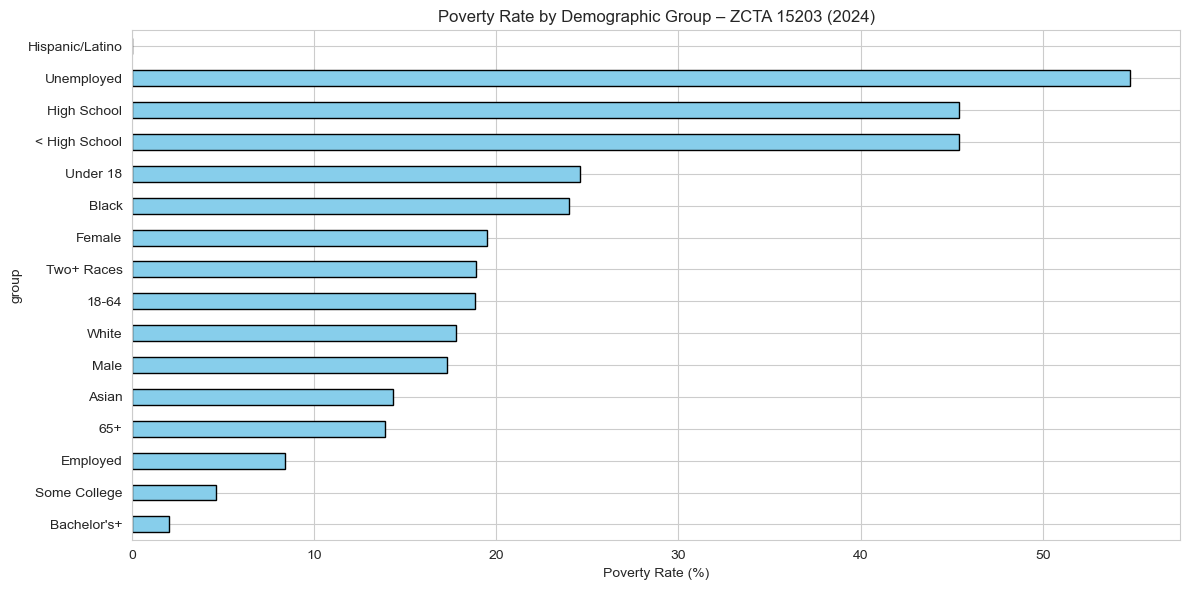

In [6]:
latest_year = years[-1]
latest = master[(master['year'] == latest_year) &
                (~master['group'].isin(['Population Total']))].copy()
latest = latest.sort_values('poverty_pct', ascending=True)

plt.figure()
latest.plot(kind='barh', x='group', y='poverty_pct', color='skyblue',
            edgecolor='black', legend=False, ax=plt.gca())
plt.xlabel('Poverty Rate (%)')
plt.title(f'Poverty Rate by Demographic Group – ZCTA 15203 ({latest_year})')
plt.tight_layout()
plt.show()


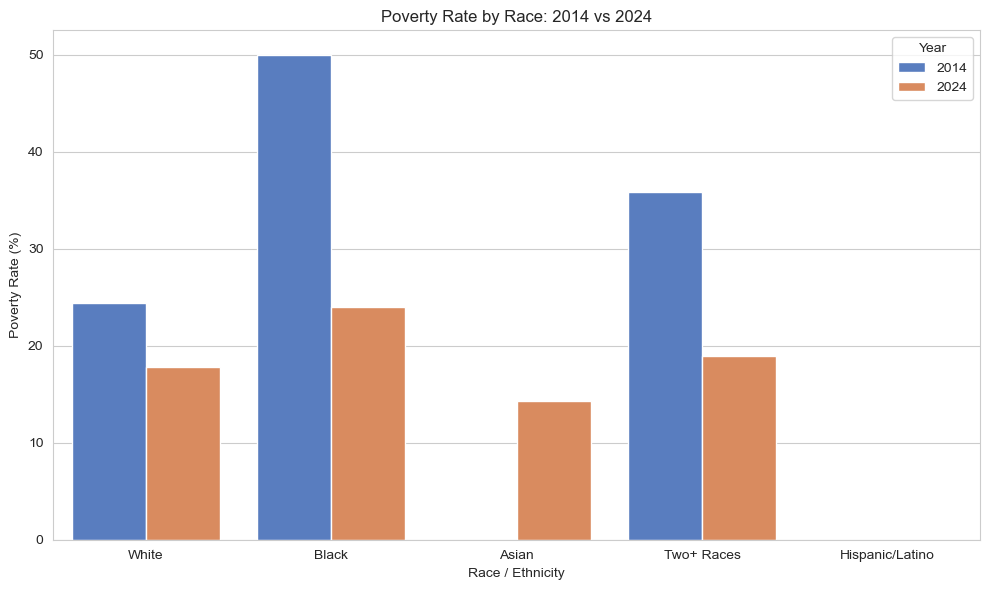

In [7]:
compare_years = [years[0], years[-1]]
race_groups = ['White', 'Black', 'Asian', 'Two+ Races', 'Hispanic/Latino']
race_compare = master[(master['year'].isin(compare_years)) &
                      (master['group'].isin(race_groups))].copy()

plt.figure(figsize=(10, 6))
sns.barplot(data=race_compare, x='group', y='poverty_pct', hue='year', palette='muted')
plt.xlabel('Race / Ethnicity')
plt.ylabel('Poverty Rate (%)')
plt.title(f'Poverty Rate by Race: {compare_years[0]} vs {compare_years[1]}')
plt.legend(title='Year')
plt.tight_layout()
plt.show()


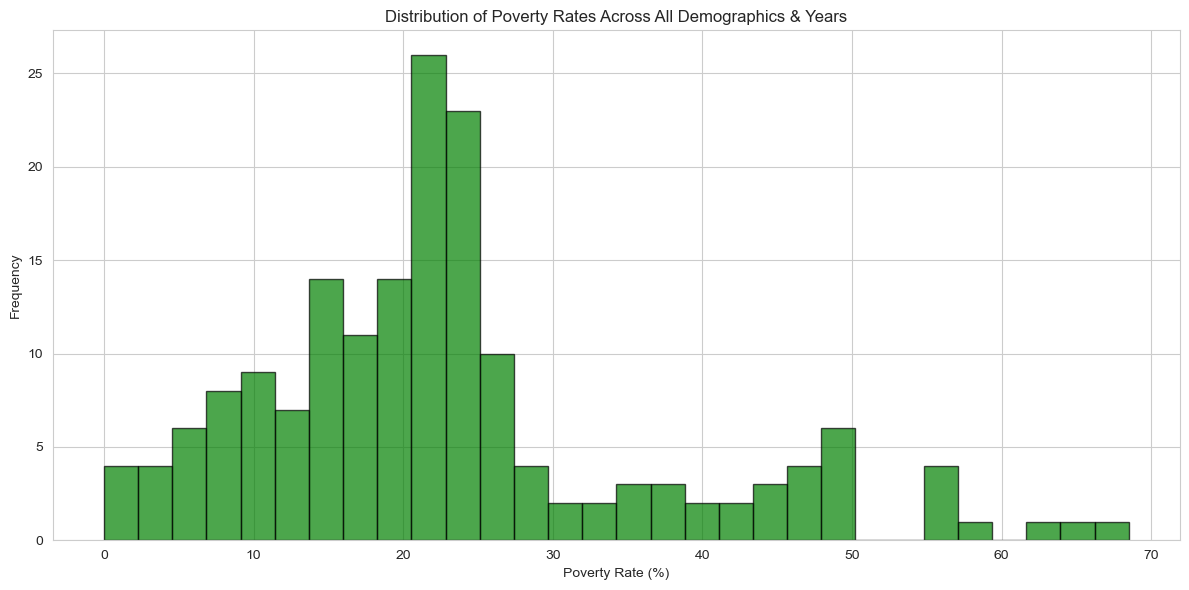

In [8]:
all_pcts = master['poverty_pct'].dropna()

plt.figure()
plt.hist(all_pcts, bins=30, edgecolor='black', alpha=0.7, color='green')
plt.xlabel('Poverty Rate (%)')
plt.ylabel('Frequency')
plt.title('Distribution of Poverty Rates Across All Demographics & Years')
plt.tight_layout()
plt.show()


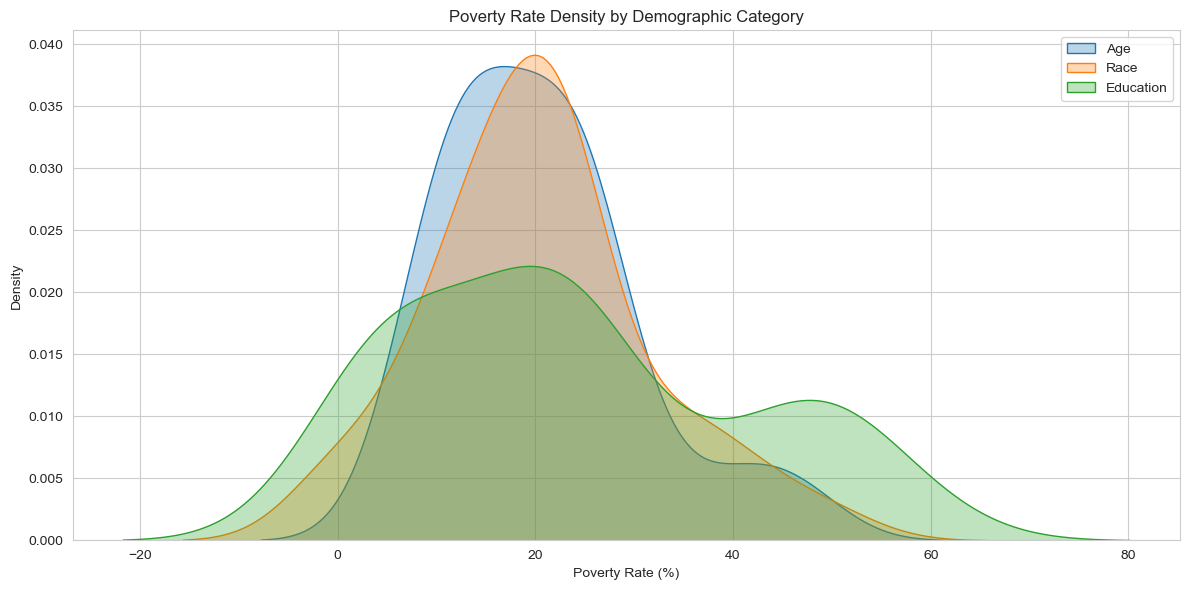

In [9]:
plt.figure()
for cat in ['Age', 'Race', 'Education']:
    data = master[master['category'] == cat]['poverty_pct'].dropna()
    sns.kdeplot(data, label=cat, fill=True, alpha=0.3)
plt.xlabel('Poverty Rate (%)')
plt.ylabel('Density')
plt.title('Poverty Rate Density by Demographic Category')
plt.legend()
plt.tight_layout()
plt.show()


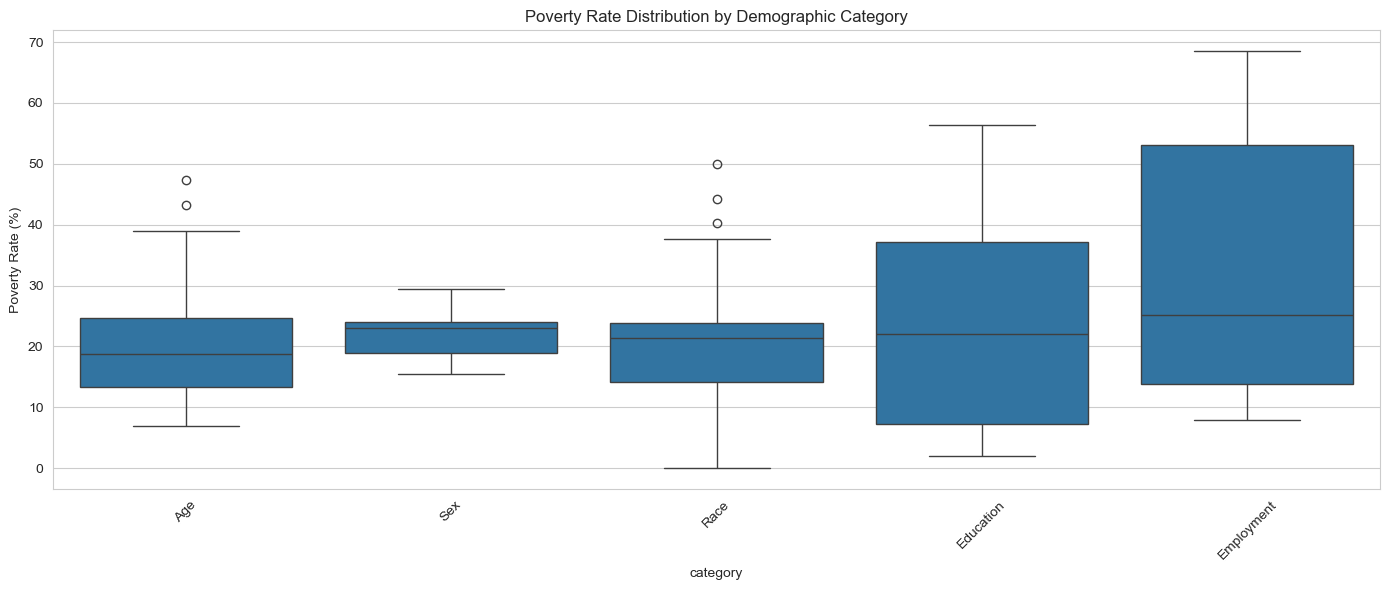

In [10]:
box_data = master[master['category'].isin(['Age', 'Race', 'Education', 'Sex', 'Employment'])]

plt.figure(figsize=(14, 6))
sns.boxplot(data=box_data, x='category', y='poverty_pct')
plt.xticks(rotation=45)
plt.ylabel('Poverty Rate (%)')
plt.title('Poverty Rate Distribution by Demographic Category')
plt.tight_layout()
plt.show()


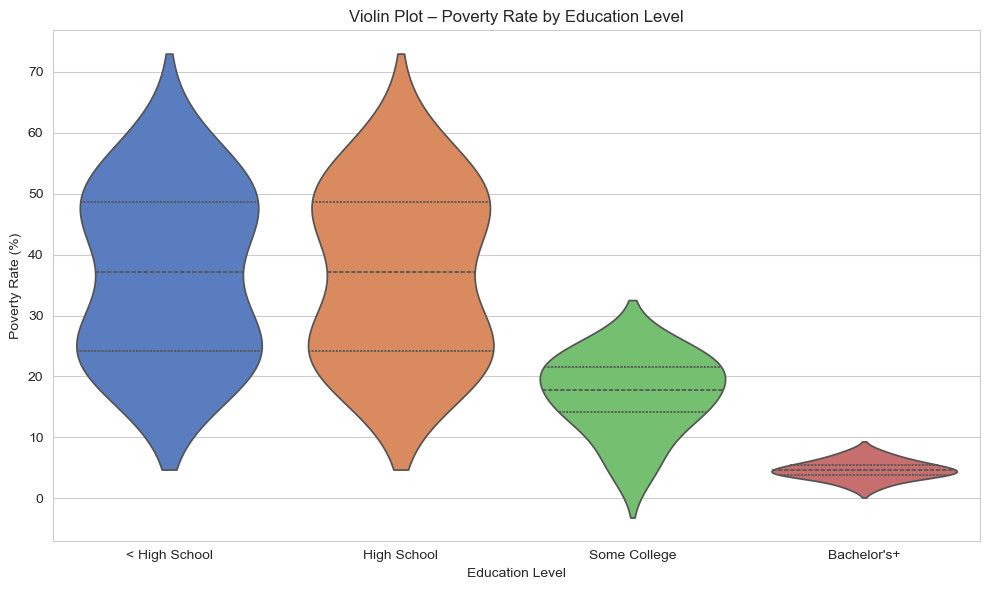

In [11]:
edu_groups = ['< High School', 'High School', 'Some College', "Bachelor's+"]
edu_violin = master[master['group'].isin(edu_groups)]

plt.figure(figsize=(10, 6))
sns.violinplot(data=edu_violin, x='group', y='poverty_pct',
               hue='group', palette="muted", inner="quartile", legend=False)
plt.xlabel('Education Level')
plt.ylabel('Poverty Rate (%)')
plt.title('Violin Plot – Poverty Rate by Education Level')
plt.tight_layout()
plt.show()


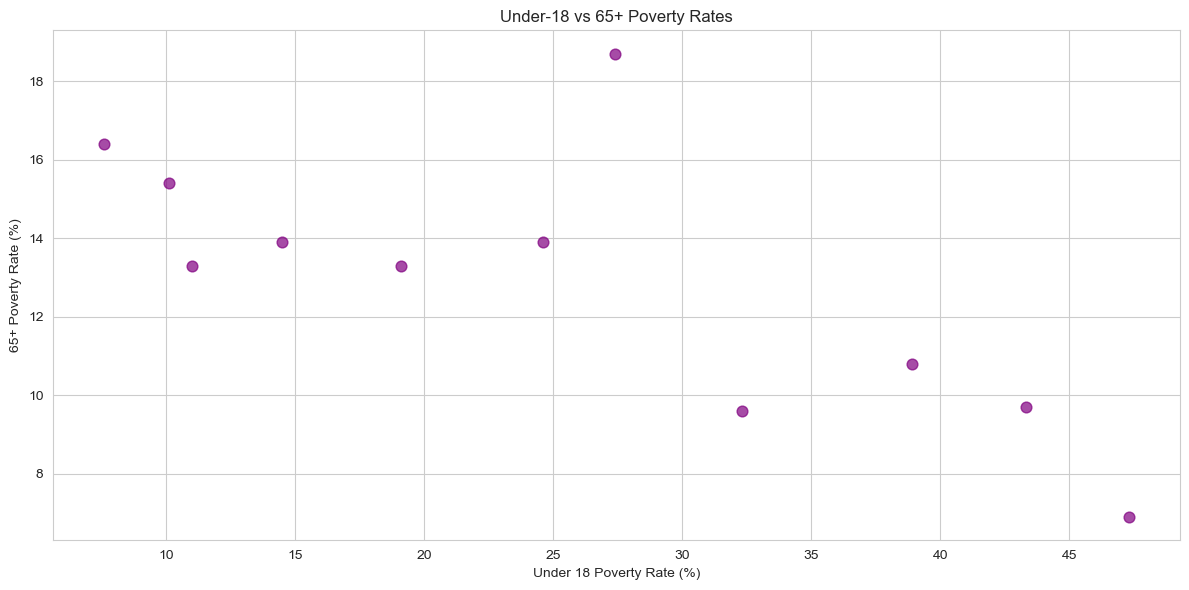

In [12]:
pivot_age = master[master['group'].isin(['Under 18', '65+'])].pivot_table(
    index='year', columns='group', values='poverty_pct').dropna()

plt.figure()
plt.scatter(pivot_age['Under 18'], pivot_age['65+'], alpha=0.7, s=60, c='purple')
plt.xlabel('Under 18 Poverty Rate (%)')
plt.ylabel('65+ Poverty Rate (%)')
plt.title('Under-18 vs 65+ Poverty Rates')
plt.grid(True)
plt.tight_layout()
plt.show()


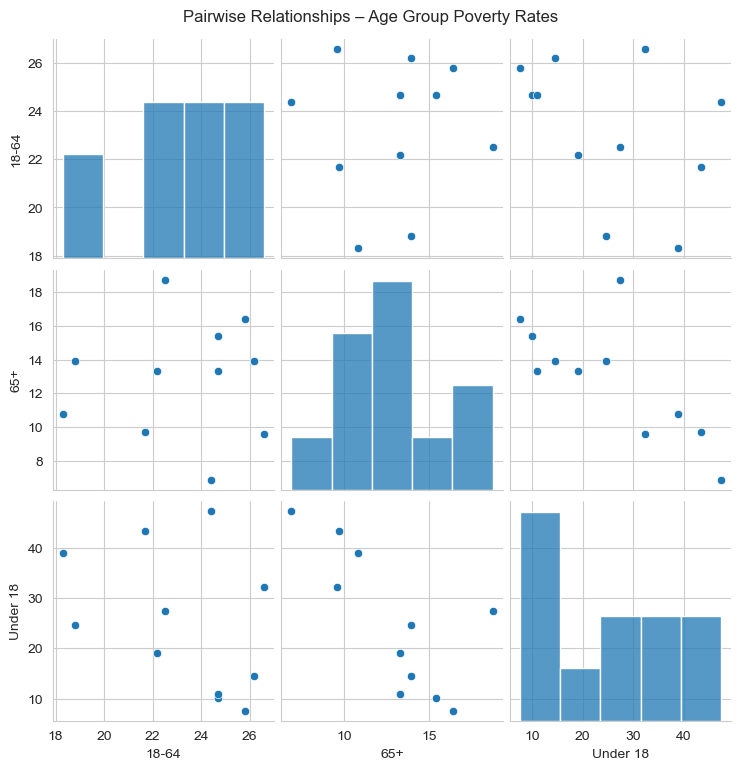

In [13]:
pair_groups = ['Under 18', '18-64', '65+']
pair_pivot = master[master['group'].isin(pair_groups)].pivot_table(
    index='year', columns='group', values='poverty_pct').dropna()

sns.pairplot(pair_pivot)
plt.suptitle('Pairwise Relationships – Age Group Poverty Rates', y=1.02)
plt.show()


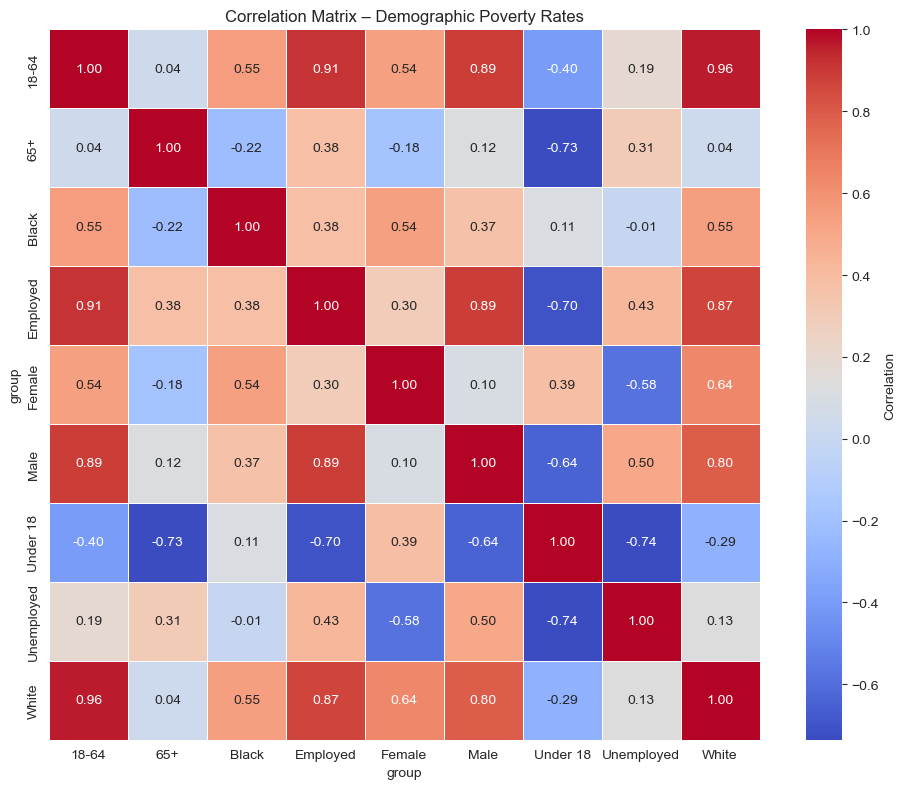

In [14]:
heat_groups = ['Under 18', '18-64', '65+', 'Male', 'Female',
               'White', 'Black', 'Employed', 'Unemployed']
heat_pivot = master[master['group'].isin(heat_groups)].pivot_table(
    index='year', columns='group', values='poverty_pct').dropna()

corr = heat_pivot.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix – Demographic Poverty Rates')
plt.tight_layout()
plt.show()


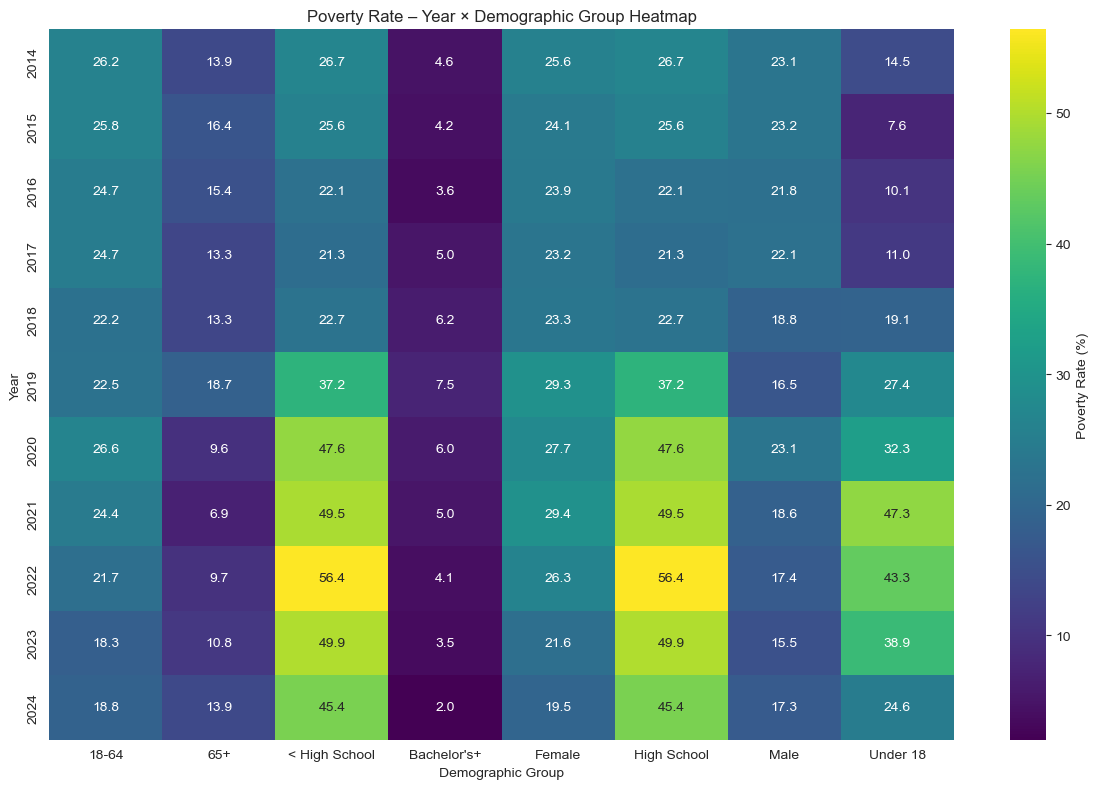

In [15]:
heat_groups2 = ['Under 18', '18-64', '65+', 'Male', 'Female',
                '< High School', 'High School', "Bachelor's+"]
heatmap_data = master[master['group'].isin(heat_groups2)].pivot_table(
    index='year', columns='group', values='poverty_pct')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='viridis', annot=True, fmt='.1f',
            cbar_kws={'label': 'Poverty Rate (%)'})
plt.xlabel('Demographic Group')
plt.ylabel('Year')
plt.title('Poverty Rate – Year × Demographic Group Heatmap')
plt.tight_layout()
plt.show()


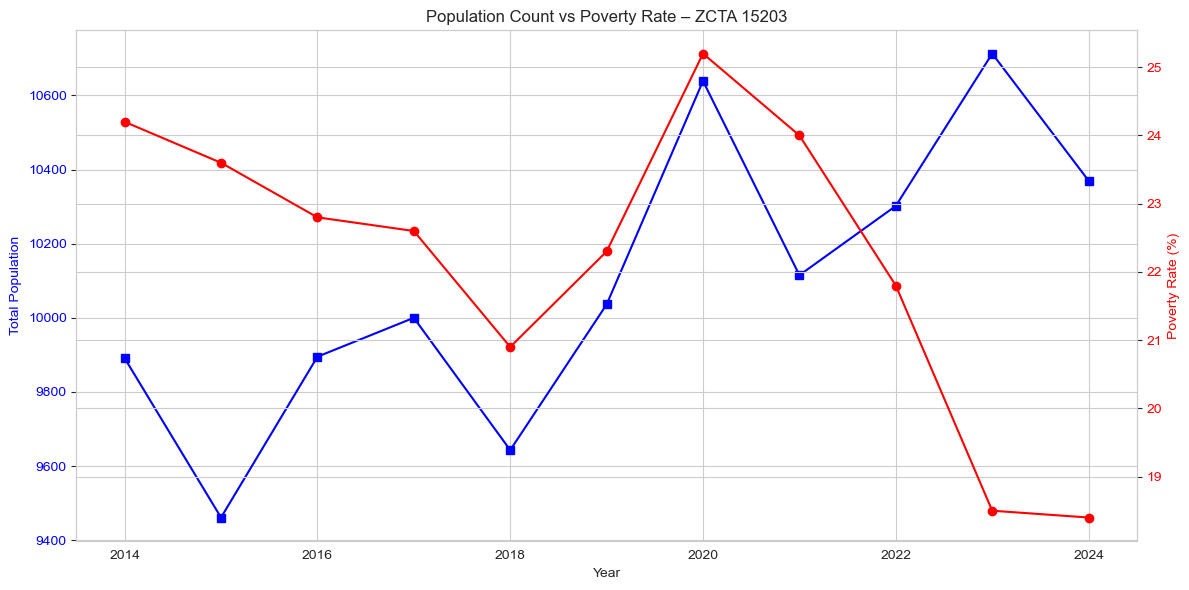

In [16]:
overall_total = []
overall_pct = []
for y in years:
    row = find_row(data_frames[y], "population for whom poverty status is determined")
    overall_total.append(get_total(row))
    overall_pct.append(get_pct(row))

fig, ax1 = plt.subplots()

ax1.plot(years, overall_total, color='blue', marker='s', label='Total Population')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Population', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(years, overall_pct, color='red', marker='o', label='Poverty Rate')
ax2.set_ylabel('Poverty Rate (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Population Count vs Poverty Rate – ZCTA 15203')
fig.tight_layout()
plt.show()


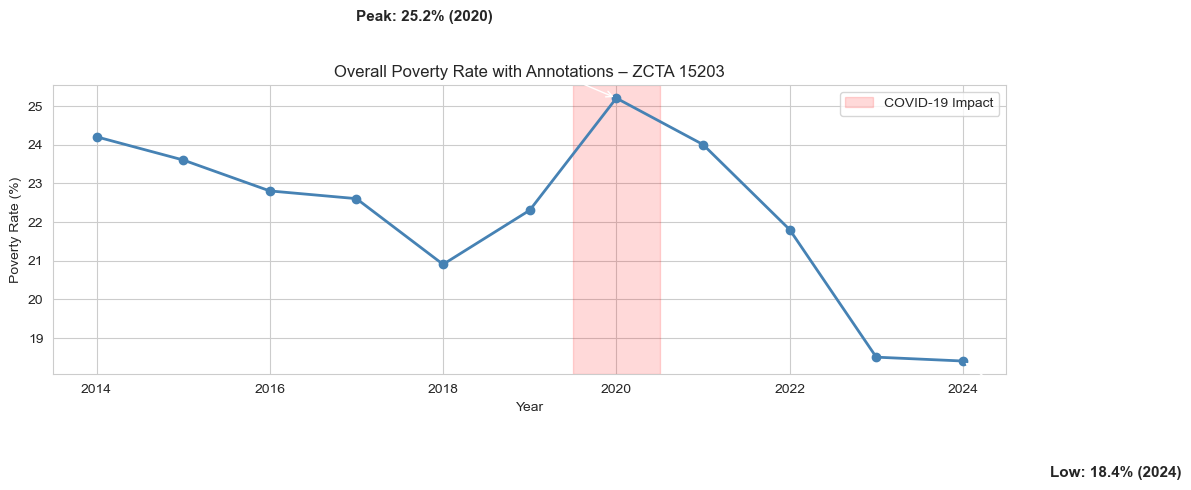

In [17]:
plt.figure()
plt.plot(years, overall_pct, linewidth=2, marker='o', color='steelblue')

# Annotate peak
peak_idx = np.argmax(overall_pct)
peak_year = years[peak_idx]
peak_val = overall_pct[peak_idx]
plt.annotate(f'Peak: {peak_val}% ({peak_year})',
             xy=(peak_year, peak_val),
             xytext=(peak_year - 3, peak_val + 2),
             arrowprops=dict(arrowstyle='->'),
             fontsize=11, fontweight='bold')

# Annotate lowest
low_idx = np.argmin(overall_pct)
low_year = years[low_idx]
low_val = overall_pct[low_idx]
plt.annotate(f'Low: {low_val}% ({low_year})',
             xy=(low_year, low_val),
             xytext=(low_year + 1, low_val - 3),
             arrowprops=dict(arrowstyle='->'),
             fontsize=11, fontweight='bold')

# COVID highlight
plt.axvspan(2019.5, 2020.5, alpha=0.15, color='red', label='COVID-19 Impact')

plt.xlabel('Year')
plt.ylabel('Poverty Rate (%)')
plt.title('Overall Poverty Rate with Annotations – ZCTA 15203')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


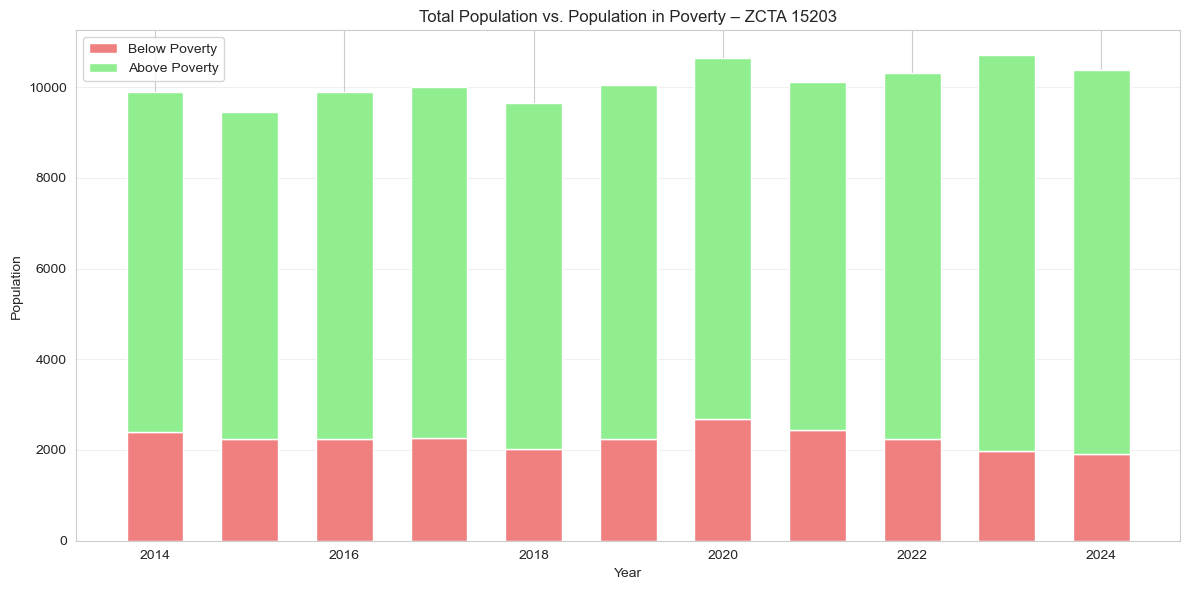

In [18]:
totals = []
below_counts = []
for y in years:
    row = find_row(data_frames[y], "population for whom poverty status is determined")
    totals.append(get_total(row))
    below_counts.append(get_below(row))

above_counts = [t - b if t and b else 0 for t, b in zip(totals, below_counts)]

plt.figure()
plt.bar(years, below_counts, label='Below Poverty', color='lightcoral', width=0.6)
plt.bar(years, above_counts, bottom=below_counts, label='Above Poverty', color='lightgreen', width=0.6)
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Total Population vs. Population in Poverty – ZCTA 15203')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
